# Week of 2025.03.17

Here are my goals for this week:

- Work through math for stability conditions again and verify analytical results agree. 
- Verify that Mario knows how to implement slip.
- Continue to noodle on the negative velocity feature. It appears to go away when time steps are small. Chat to Eric about a mitigation, or maybe it doesn't really matter. 
- Review differential equation for slip. Calculate analytical solution for slip to compare to numerical simulation. 

## 1.0 Stability analysis reviewed 

**Note:** The below calculations assume $L_{plug} >> s$. 

Let's review the dynamics of our system: 

$$
M \ddot{s} = A (p_0 + \Delta p(s)) - p_{atm} A - 2 \pi R L_{plug} \tau(s)
$$

When the system is at equilibrium, the following is true:

$$
0 = A (p_0 - p_{atm}) - 2 \pi R L_{plug} \tau_p
$$

Equilibrium therefore implies 

$$
p_0 = p_{atm} + \frac{2 L \tau_p}{R}
$$

### 1.0.1 As a quick aside, lets review our steady state solution for our current parameters

$$
\begin{align}
P_0 &= p_{atm} + \frac{2 L \tau_p}{R} \\

P_0 &= 1e5 [Pa] + \frac{2 * 100 [m] * 2e5 [Pa]}{10m} \\
P_0 &= 4.1e6 [Pa]
\end{align}
$$

Note, that we expect to see a linear pressure gradient of $p_{atm}$ -> $p_{0}$ across the plug, and then we expect to see the melt exist at the steady state pressure of $p_0$. 

### 1.0.2 Stability conditions at steady state

To consider what values of $D_c$ and $s$ result in stability at equilibrium lets consider the dynamic equation at equilibirum. Enforcing the equlibrium conditions allows us to remove dependence on $p_0$ and $p_{atm}$. We get a new dynamics equation, at equilibrium of: 

$$
M \ddot{s} = A  \Delta p(s) + (\tau_p - \tau(s)) 2 \pi R L_{plug}
$$

Intuitively, this means that if $ - A \Delta p(s) = (\tau_p - \tau(s)) 2 \pi R L_{plug}$ there will be no acceleration. At $s=0$ those two terms are equal ($ \Delta p(s) = 0$ and $\tau_s = \tau_p$). 

The forces on both sides of the above equation are weakening forces. If (as s increases above 0), the $ A \Delta (p(s))$ grows more quickly is magnitude than $(\tau_p - \tau(s)) 2 \pi R L_{plug}$ that implies stability. Conversely, if the friction weakens more quickly than the pressure term, than the system will be unstable. Mathmatically, the system in unstable when:

$$
\begin{align}
F_p(s) &= A \Delta p(s) \\
F_f(s) &= (\tau_p - \tau(s)) 2 \pi R L_{plug} \\
\frac{|\frac{d F_p}{ds}|}{|\frac{d F_f}{ds}|} &< 1
\end{align}
$$

In English, this states that the system is unstable when the pressure force decreases more slowly than the frictional force decreases. 

### 1.0.3 Fluid compressibility review
Let's review fluid compressibility and bulk modulus briefly before calculating the derivatives: 

$$
\begin{align}
K &= - V \frac{dP}{dV} \\
K &= - A * L \frac{dP}{dL * A} \\
K &= - L \frac{dP}{dL}
\end{align}
$$

### 1.0.4 Tau frictional force law (linear)
Recall that our linear model of $\tau$ is expressed like

$$ \tau(s) = \tau_p - (\tau_p - \tau_r) * \frac{s}{D_c} $$


### 1.0.5 Derivatives
$$ 
\begin{align}
\frac{d F_P}{ds} &= A * \frac{dP}{ds} = \frac{-A * K}{L_{conduit}} \\
\frac{d F_f}{ds} &= 2 \pi R L_{plug} \frac{\tau_p - \tau_r}{D_c}
\end{align}
$$

### 1.0.6 $D_c$ as a function of $\tau_p$ and $\tau_r$ for instability
Instability conditions
$$
\begin{align}
\frac{|\frac{d F_p}{ds}|}{|\frac{d F_f}{ds}|} &< 1 \\ \\
\frac{\frac{A * K}{L_{conduit}}}{2 \pi R L_{plug} \frac{\tau_p - \tau_r}{D_c}} &< 1 \\ \\
\frac{A K D_c}{L_{conduit} 2 \pi R L_{plug} (\tau_p - \tau_r)} &< 1
\end{align}
$$

So this results in an instability condition of 

$$
\begin{align}
D_c < \frac{L_{conduit} 2 \pi R L_{plug} (\tau_p - \tau_r)}{A K } \\
D_c < \frac{2 L_{conduit} L_{plug} (\tau_p - \tau_r)}{R K } \\
\end{align}
$$

### 1.0.7 specific D_c for certain ICs test

If $\tau_p = 2e5$ and $\tau_r = 0$, $R = 10 [m]$, $L_{plug} = 100 [m]$, and $L_{conduit} = 900 [m]$ we get:

$$
D_c < \frac{2 *  900 [m] *  100 [m] * (2e5 [Pa])}{10 [m] *  1e9 [Pa] } \\
D_c < 3.6 [m]
$$

This tells us that if D_c is less than 3.6 meters, the system will be unstable. If there is marginally more pressure than steady state, the plug will be ejected 3.6m before the loss in pressure will be greater than the reduction in friction. 

### 1.0.8 Numerical test with $D_c < 3.6 [m]$

Let's set the parameters $D_c = 3.3 [m]$ and let's set the initial pressure in the metal equal to 4.5 MPa which is slightly higher than the 4.1 MPa of steady state. 

In [6]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v1")

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


### 1.0.9 Numerical test with $D_c > 3.6 [m]$

Let's leave the parameters from above the same expect set $D_c = 3.7$. We now expect the system to quickly stabalize as the reduction in pressure happens more quickly than the fall off in pressure. 

In [7]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v4", p0=4.1)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


## 2.0 Review of negative velocity

In the steady state solution, we see a negative velocity across the plug. This is unexpected given that we expect the frictional force to be equally weighted with the force from pressure. The negative velocity reduces the finer our timesteps indicating that this negative velocity is a function of numerical error. 

In an email to me, Eric described the negative velocity as follows:

> Regarding the negative velocity, I think it is simply the issue that I mentioned the other day, that the numerical steady state can be slightly different from the analytical steady state due to approximation of d/dx. The analytical steady state has a balance between the pressure gradient pushing in the +x direction and drag pushing in the -x direction (at least the way it's implemented now). If that pressure gradient is slightly different due to numerical approximation of dp/dx, then it's possible that the pressure gradient is a little bit too small and then we get a negative net force that pushes the plug down and creates a negative velocity.

What suprises me is that the numerical solution arrives at the same $P_0$ as our analytical solution, yet still introduces this negative velocity artifact. One of the challenges with the negative velocity artifact is that it reduces slip and therefore the system does not slip into the unstable configuration that we would otherwise expect. 


### 2.0.1 Test Eric's hypothesis 

>As for negative velocity, try to test my hypothesis. From the output tau and p, calculate the pressure gradient term and the frictional drag term and check that drag force is a bit larger than pressure gradient force. If that's the case, then perhaps increase the pressure gradient a bit more in the initial condition?

Based on the below simulation, I believe Eric's hypothesis is **false**. I see that given the $\tau_p = 0.3 [MPa]$, the pressure gradient almost exactly matches our expectations. See above for the calculation expecting the pressure on the left side of the gradient to be 4.1 MPa. 

For this simulation, $D_c = 100 [m]$ (large so that the system stays stable). The fact that $p_0$ lines up for the analytical and numerical simulation implies the pressure gradient is correct in the numerical sim. 

In [11]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v2", p0=4.1)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


### 2.0.2 Negative velocities at different number of time steps. Consider three examples of the steady solution calculuated at three different size of timesteps.

#### Steady state, $\Delta t = 1/100$ $\Delta x = 5 m$

In [1]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v5", p0=4.1)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


#### Steady state, $\Delta t = 1/1000$, $\Delta x = 1m$

In [4]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v6", p0=4.1)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


#### Steady state, $\Delta t = 1/4000$, $\Delta x = 1/4 m$

In [5]:
from slip_imports import *

ani = animate.animate_conduit_pressure("slip_variable_addition", iterations=100, file_prefix="short_plug_v7", p0=4.1)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


## 3.0 Look at Mario's config file and see why it requires so many timesteps

The [Courant Friedrich Lewy condition](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition) relates max wave speed with required time step. 

$$\frac{u \Delta t}{\Delta x} \leq C_{max}$$

$C_{max}= 1$ because we are using an explicit time step method (according to wikipedia), so:

$$
\frac{\Delta x}{\Delta t} = u
$$

In the below example, wave speed maxes out at 250 m/s and $\Delta x = 10m$, so the $\Delta t$ is on the order $\frac{1}{1000}$. Therefore I think Mario's time step is already as small as we can reasonably make it unless we reduce wave speed. 

In [ ]:
from slip_imports import *

ani = animate.animate_conduit_pressure("test_for_mario", iterations=25, file_prefix="tungurahua_rad_5_v14_conduit", viscosity_index=1, wall_friction_index=4, p0=4.1, x_min=-1000, max_speed_of_sound=1000, max_pressure=50, max_velocity=120)

HTML(ani.to_html5_video())

/Users/paxton/git/quail_volcano/scenarios/simple_1D_test


## 4.0 Solving the differential equation for slip

It is interesting to solve the differential equation for slip and compare to the results in our numerical simulation. This simulation ignores:
1. viscous drag
2. added mass effect 

But it should give us a sanity check that the numbers we see in the above simulations (specifically 1.0.8 and 1.0.9 are legitimate).

From above, recall that our differential equation is (I am removing the simplifying assumption that $L_{plug} >> s$).

$$
\begin{align}
M \ddot{s} &= A (p_0 + \Delta p(s)) - p_{atm} A - 2 \pi R L_{plug} \tau(s) \\
M \ddot{s} &= A * (p_0 - p_{atm} + \Delta p (s)) - \tau(s) * 2 \pi R (L_{plug} - s) \\
M \ddot{s} &= A * (p_0 - p_{atm} - \frac{K s}{L_{melt}})  - \tau (s) * 2 \pi R (L_{plug}-s) \\
\end{align}
$$

Let's rewrite that as a two first order differential equations and then solve numerically for our parameters. Let's call slip $s_1$ and it's derivate $s_2$
$$
\begin{align}
s_2 &= \dot{s_1} \\
\dot{s_2} &= \frac{A}{M} * (p_0 - p_{atm} - \frac{K s_1}{L_{melt}})  - \frac{\tau (s_1) * 2 \pi R (L_{plug}-s_1)}{M} \\
\end{align}
$$

D_c: 3.5


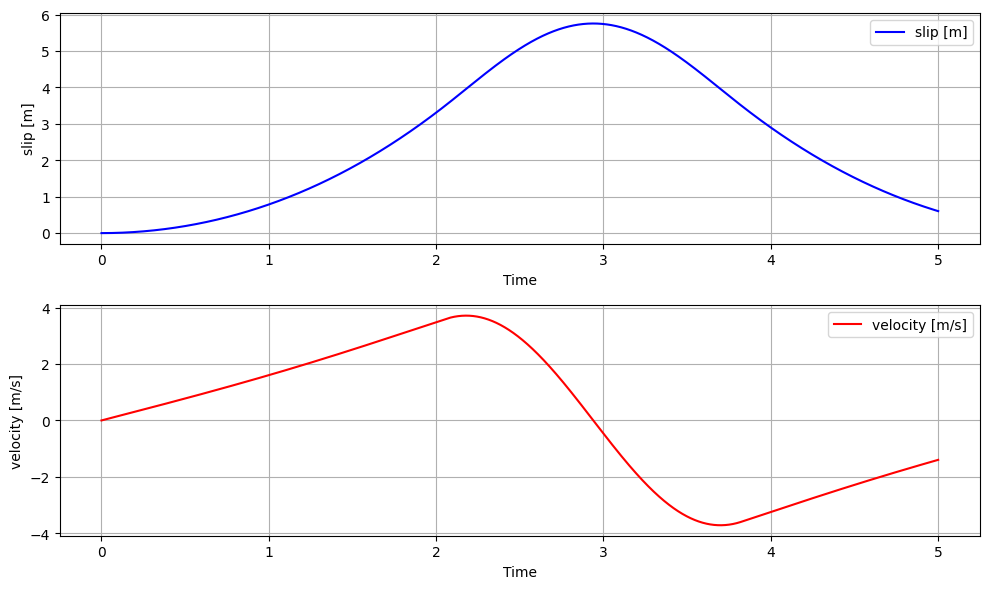

Slip: 0.6035
Velocity: -1.3967


In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define constants (you can modify these values as needed)
K = 1e9      # Some constant (friction/damping)
L_melt = 900 # Melt length
tau_p = 2e5  # principle shear stress
tau_r = 0  # residual shear stress
R = 10      # Radius [m]
L_plug = 100 # Plug length

M_plug = R**2 * np.pi * L_plug * 2.6e3    # Mass

# Account for adding mass effect.
M_eff = M_plug * (1 + L_melt / (L_plug*2))
D_c = 3.5

A = np.pi * R**2  # Cross-sectional area
p0 = 4.5e6  # Pressure at the top of the conduit
p_atm = 1e5  # Atmospheric pressure

def tau(s):
    #return tau_r - (tau_r - tau_p) * np.exp(s / D_c)

    if s < D_c:
        return tau_p - (tau_p - tau_r) * s / D_c
    else:
        return tau_r

# Define the system of differential equations
def system(state, t):
    s1, s2 = state  # s1 is position, s2 is velocity
    
    # ds1/dt = s2
    ds1_dt = s2
    
    # ds2/dt = (-A*K*s2)/(M*L_melt) + ((tau_p - tau_s)*2*pi*R*(L_plug - s1)*s1)/M
    ds2_dt = (-A * K * s1) / (M_eff * L_melt) + A * (p0 - p_atm) / M_eff - \
             (tau(s1) * 2 * np.pi * R * (L_plug - s1)) / M_eff
    
    return [ds1_dt, ds2_dt]

# Initial conditions
s1_0 = 0.0  # Initial position
s2_0 = 0.0  # Initial velocity
initial_state = [s1_0, s2_0]

# Time points
t = np.linspace(0, 5, 10000)  # Time from 0 to 10 with 1000 points

# Solve the differential equations
solution = odeint(system, initial_state, t)

# Extract solutions
s1 = solution[:, 0]  # Position
s2 = solution[:, 1]  # Velocity

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, s1, 'b-', label='slip [m]')
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('slip [m]')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, s2, 'r-', label='velocity [m/s]')
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('velocity [m/s]')
plt.legend()

print(f"D_c: {D_c}")
plt.tight_layout()
plt.show()

# Optional: Print some key values
print(f"Slip: {s1[-1]:.4f}")
print(f"Velocity: {s2[-1]:.4f}")

### 4.1 Observations:
- Without viscous drag it the system is undamped which results in greater slip for a given D_c.
- Smaller D_c values result in greater magnitude of oscillation. 
- We could add the viscous drag term in, but then we would have to assume the whole system (plug + melt) is moving at a constant velocity.  Is that worth doing? 


Text(0, 0.5, 'Velocity [m/s]')

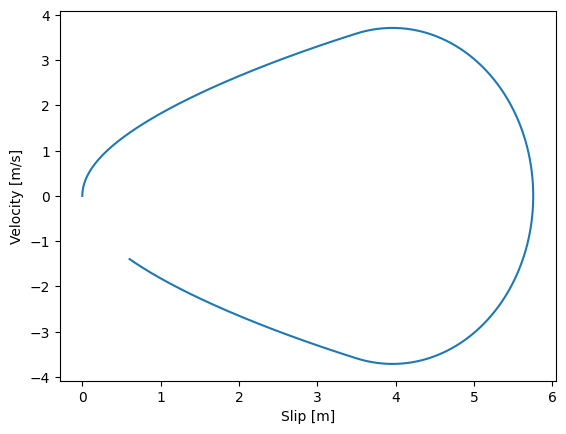

In [102]:
plt.plot(s1, s2)
plt.xlabel("Slip [m]")
plt.ylabel("Velocity [m/s]")

## A.1 Errors from added mass or viscous drag. 

It turns out that the disagreement in analytical and numerical solutions were largely a result of me not considering the effect of viscous drag. By reducing viscous drag to $5e4$ I was able to largely solve this issue. The viscous drag term probably still causes the numerical model to be slightly more stable than my analytical solutions gives it credit for, but the analytical numerical comparison is much closer now. 